In [1]:
import argparse
import torch
import time
import numpy as np 

import os 
import sys


from datasets import load_dataloaders
from model.hopfield.network import ConvHopfieldEnergy32
from model.function.network import Network
from model.function.cost import SquaredError
from model.hopfield.minimizer import FixedPointMinimizer
from training.sgd import EquilibriumProp, ContrastiveLearning, Backprop, RecurrentBackprop, AugmentedFunction
from training.epoch import Trainer, Evaluator
from training.monitor import Monitor, Optimizer

In [2]:
def build_gradient_estimator(energy_fn, cost_fn, algorithm = 'CEP', nudging = 0.25, num_iterations = 15):
    """Build the gradient estimator: either contrastive learning (CL), equilibrium propagation (EP), coupled learning (CpL) or a variant of these algorithms.

    Variants:
    * P = postively-perturbed
    * N = negatively-perturbed
    * C = centered
    e.g. CEP = centered variant of equilibrium propagation

    TBP = truncated backpropagation
    RBP = recurrent backpropagation

    Args:
        energy_fn (SumSeparableFunction): the energy_fn to train
        cost_fn (CostFunction): the cost function to optimize
        algorithm (str, optional): the gradient estimator used. Either 'CL', 'PEP', 'NEP', 'CEP', 'PCpL', 'NCpL', 'CCpL', 'TBP' or 'RBP'. Default: 'CEP'
        nudging (float, optional): the nudging value used, for equilibrium propagation (EP) and coupled learning (CpL). Default: 0.25
        num_iterations (int, optional): the number of iterations used for training. Default: 15
    
    Returns:
        the gradient estimator
    """

    params = energy_fn.params()
    layers = energy_fn.layers()
    free_layers = network.free_layers()

    if algorithm == "CL":
        energy_minimizer = FixedPointMinimizer(energy_fn, free_layers[:-1])
        energy_minimizer.mode = 'asynchronous'
        estimator = ContrastiveLearning(params, layers, energy_fn, cost_fn, energy_minimizer)
        estimator.nudging = 1.0
        estimator.variant = 'positive'
    elif algorithm[1:] == "EP":
        augmented_fn = AugmentedFunction(energy_fn, cost_fn)
        energy_minimizer = FixedPointMinimizer(augmented_fn, free_layers)
        energy_minimizer.mode = 'asynchronous'
        estimator = EquilibriumProp(params, layers, augmented_fn, cost_fn, energy_minimizer)  # FIXME
        estimator.nudging = nudging
        if algorithm == "PEP": estimator.variant = 'positive'
        elif algorithm == "NEP": estimator.variant = 'negative'
        elif algorithm == "CEP": estimator.variant = 'centered'
        else: raise ValueError("expected 'PEP', 'NEP' or 'CEP' but got {}".format(algorithm))
    elif algorithm[1:] == "CpL":
        energy_minimizer = FixedPointMinimizer(energy_fn, free_layers[:-1])
        energy_minimizer.mode = 'asynchronous'
        estimator = ContrastiveLearning(params, layers, energy_fn, cost_fn, energy_minimizer)
        estimator.nudging = nudging
        if algorithm == "PCpL": estimator.variant = 'positive'
        elif algorithm == "NCpL": estimator.variant = 'negative'
        elif algorithm == "CCpL": estimator.variant = 'centered'
        else: raise ValueError("expected 'PCpL', 'NCpL' or 'CCpL' but got {}".format(algorithm))
    elif algorithm == "TBP":
        energy_minimizer = FixedPointMinimizer(energy_fn, free_layers)
        energy_minimizer.mode = 'asynchronous'
        estimator = Backprop(params, layers, cost_fn, energy_minimizer)
    elif algorithm == "RBP":
        energy_minimizer = FixedPointMinimizer(energy_fn, free_layers)
        energy_minimizer.mode = 'synchronous'
        estimator = RecurrentBackprop(params, layers, cost_fn, energy_minimizer)
    else:
        raise ValueError("expected 'CL', 'PEP', 'NEP', 'CEP', 'PCpL', 'NCpL', 'CCpL', 'TBP' or 'RBP' but got {}".format(algorithm))

    energy_minimizer.num_iterations = num_iterations

    return energy_minimizer, estimator


In [3]:

b_mult = 1
s_mult = 1
iter_mult = 1
inf_iter_mult = 1
nudge_mult = 1
epoch_mult = 1
moment_mult = 1
decay_mult = 1

dataset = "MNIST"
algorithm = "CEP"

# Load the training and test data (either MNIST, Fashion-MNIST, SVHN, CIFAR-10 or CIFAR-100)
batch_size = int(128 * b_mult)
training_loader, test_loader = load_dataloaders(dataset, batch_size, augment_32x32=True)  # if the dataset is MNIST or Fashion-MNIST, we augment the input images to 32x32 pixels

# Specify the number of input filters and output units of the network, depending on the dataset
if dataset in ['MNIST', 'FashionMNIST']: num_inputs = 1
else: num_inputs = 3

if dataset == 'CIFAR100': num_outputs = 100
else: num_outputs = 10

# Build the network (a convolutional Hopfield net with 32x32-pixel input images)
gain = 0.5
weight_gains = [gain, gain, gain, gain, gain]
energy_fn = ConvHopfieldEnergy32(num_inputs, num_outputs, weight_gains=weight_gains)

if torch.cuda.is_available(): device = "cuda"
elif torch.mps.is_available(): device = "mps"
else: device = "cpu"
energy_fn.set_device(device)

# Define the cost function (mean squared error)
output_layer = energy_fn.layers()[-1]
cost_fn = SquaredError(output_layer)
network = Network(energy_fn)

# Define the gradient estimator (either CL, EP, CpL, or a variant of these algorithms)
nudging = (nudge_mult * 0.25)
num_iterations_training = int(iter_mult* 15)
energy_minimizer_training, estimator = build_gradient_estimator(energy_fn, cost_fn, algorithm, nudging, num_iterations_training)

# Build the optimizer (SGD with momentum and weight decay)
learning_rates_weights = list(s_mult* np.array([0.0625, 0.0375, 0.025, 0.02, 0.0125]))
learning_rates_biases = list(s_mult* np.array([0.0625, 0.0375, 0.025, 0.02, 0.0125]))
learning_rates = learning_rates_biases + learning_rates_weights

momentum = 0.9 * moment_mult 
weight_decay = 3 * 1e-4 * decay_mult
# optimizer = build_optimizer(energy_fn, learning_rates, momentum, weight_decay)
optimizer = Optimizer(energy_fn, cost_fn, learning_rates, momentum, weight_decay)

# Define the trainer (to perform one epoch of training) and the evaluator (to evaluate the model on the test set)
params = energy_fn.params()
layers = energy_fn.layers()
free_layers = network.free_layers()
num_iterations_inference = int(inf_iter_mult * 60)
energy_minimizer_inference = FixedPointMinimizer(energy_fn, free_layers)
energy_minimizer_inference.num_iterations = num_iterations_inference
trainer = Trainer(network, cost_fn, params, training_loader, estimator, optimizer, energy_minimizer_inference)
evaluator = Evaluator(network, cost_fn, test_loader, energy_minimizer_inference)

# Define the scheduler for the learning rates (cosine annealing scheduler)
num_epochs = int(epoch_mult * 100)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=2.*1e-6)

# Define the path and the monitor to perform the run
path = '/'.join(['papers/ebl-algorithms/comparison', dataset, algorithm])
monitor = Monitor(energy_fn, cost_fn, trainer, scheduler, evaluator, path)

# Print the characteristics of the run
print('Dataset: {} -- batch_size={}'.format(dataset, batch_size))
print('Network: ', energy_fn)
print('Cost function: ', cost_fn)
print('Energy minimizer during inference: ', energy_minimizer_inference)
print('Energy minimizer during training: ', energy_minimizer_training)
print('Gradient estimator: ', estimator)
print('Parameter optimizer: ', optimizer)
print('Number of epochs = {}'.format(num_epochs))
print('Path = {}'.format(path))
print('Device = {}'.format(device))
print()

# Launch the experiment
monitor.run(num_epochs, verbose=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 14.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 2.79MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 13.9MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 1.73MB/s]


Dataset: MNIST -- batch_size=128
Network:  ConvHopfieldEnergy32 -- size=[1, 128, 256, 512, 512, 10], activation=hard-sigmoid, pooling=conv_max_pool, gains=[0.5, 0.5, 0.5, 0.5, 0.5]
Cost function:  Squared Error (MSE)
Energy minimizer during inference:  Fixed point minimizer -- mode=asynchronous, num_iterations=60
Energy minimizer during training:  Fixed point minimizer -- mode=asynchronous, num_iterations=15
Gradient estimator:  Equilibrium propagation -- mode=centered, nudging=0.25, formula=standard
Parameter optimizer:  SGD -- initial learning rates = [0.0625, 0.0375, 0.025, 0.02, 0.0125, 0.0625, 0.0375, 0.025, 0.02, 0.0125], momentum=0.9, weight_decay=0.00030000000000000003
Number of epochs = 100
Path = papers/ebl-algorithms/comparison/MNIST/CEP
Device = mps

Epoch 1
TRAIN -- Example 56832/60000, Energy = -3364.05, Cost = 0.16423, Error = 21.940%, Top5Error = 7.436%%

KeyboardInterrupt: 

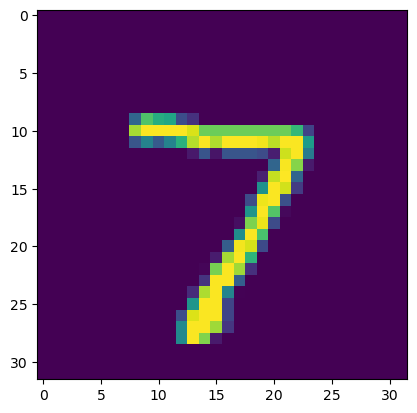

tensor([7], device='mps:0')
tensor([2], device='mps:0')


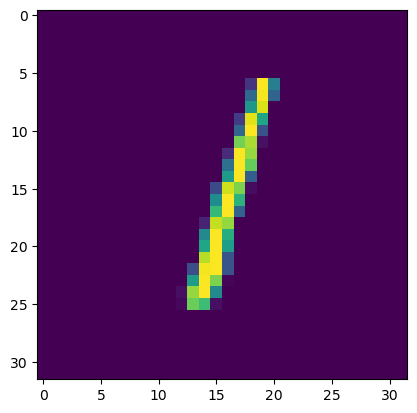

tensor([1], device='mps:0')


In [4]:
import matplotlib.pyplot as plt
for x, y, idx in evaluator._dataloader:
    for i in range(0,3):

        evaluator._network.set_input(x[i:i+1, 0:1, :, :], reset=True)
        evaluator._energy_minimizer.compute_equilibrium()

        evaluator._idx = idx
        output = evaluator._cost_fn._get_output()  # state of output layer

        if(i ==0):
            output_for_7= output
            image_for_7 = x[i,0, :, :].reshape(1,1,32,32)
            plt.imshow(image_for_7[0,0,:,:]);
            plt.show();
        if(i ==2): 
            output_for_1 = output
            image_for_1 = x[i,0, :, :].reshape(1,1,32,32)
            plt.imshow(image_for_1[0,0,:,:]);
        plt.show()
        prediction = torch.argmax(output, dim=1)  # the predicted category is the index of the output unit that has the highest value
        print(prediction)
    break;

100%|██████████| 200/200 [00:51<00:00,  3.85it/s, loss=0.000737]
/var/folders/q0/hw11rnjs0g1cnny7p5swsnv40000gn/T/ipykernel_60325/3056440605.py:56: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1731397169486/work/torch/csrc/utils/tensor_new.cpp:257.)
  return estimated_input.cpu(), torch.tensor(all_probs), loss_values, snapshots


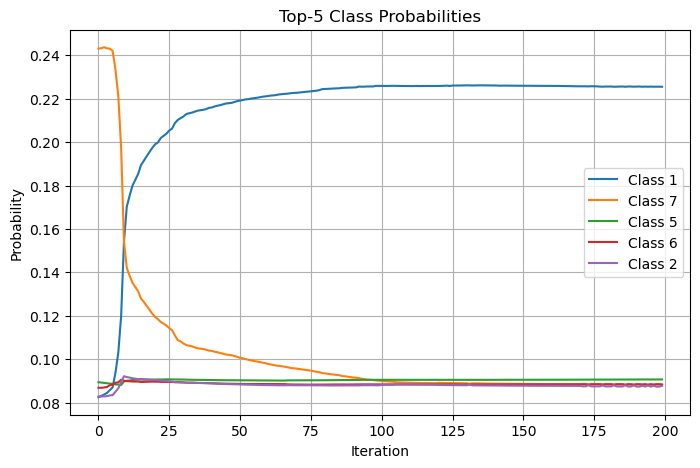

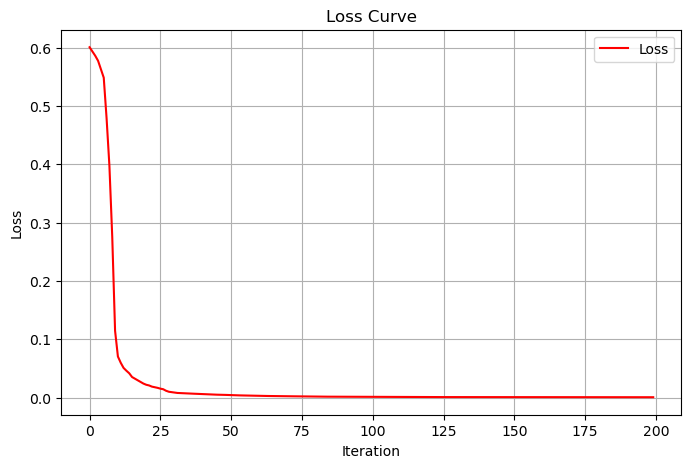

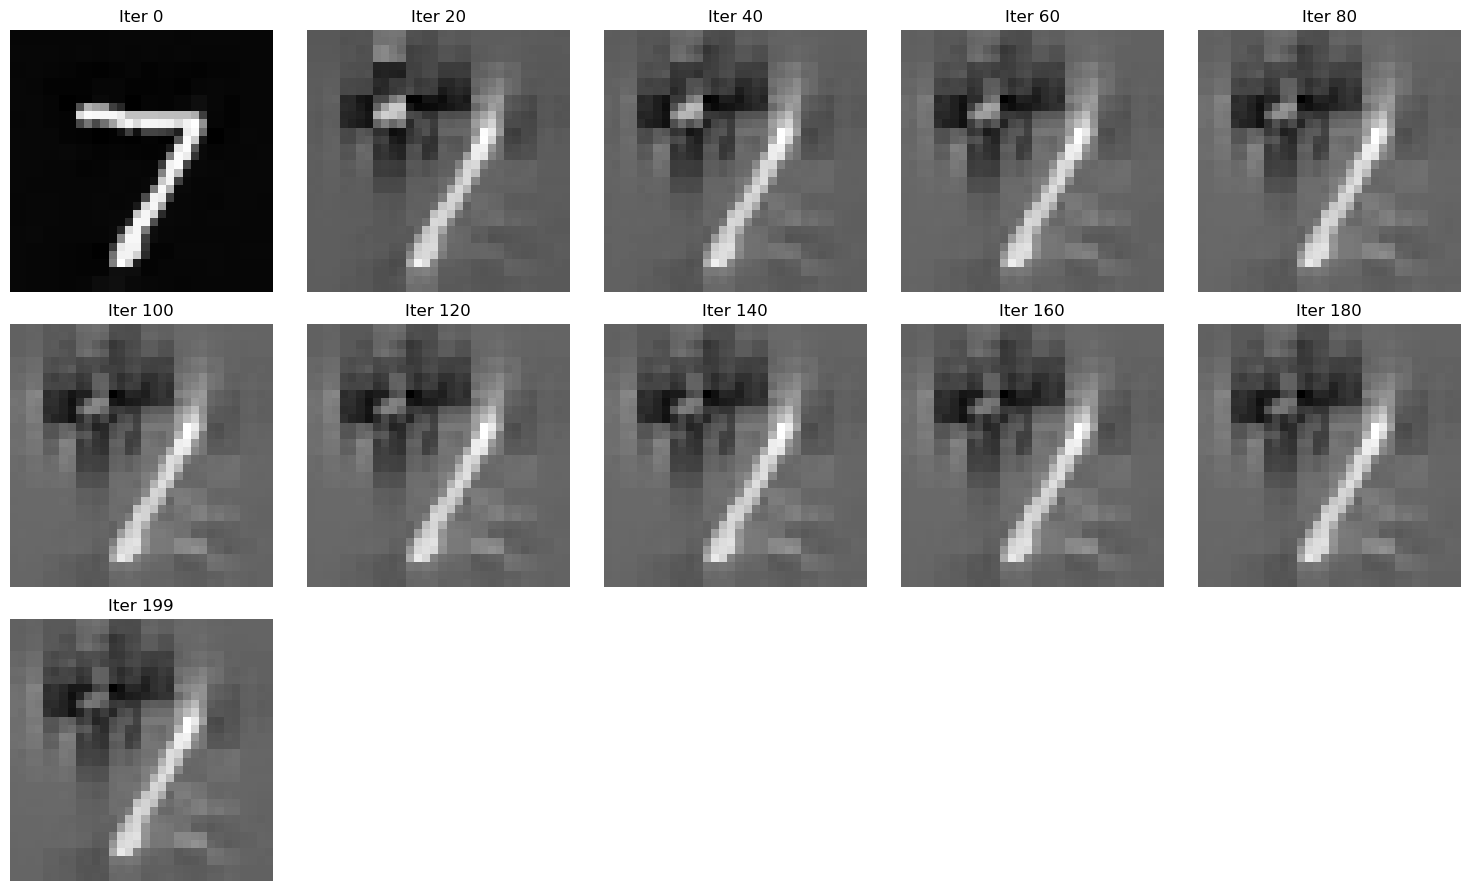

In [5]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm import tqdm
import random
import math

device = torch.device("mps")

def weighted_loss(pred, target, weight_high=5.0, weight_low=1.0):
    weight = torch.where(target > 0.8, weight_high, weight_low)
    return torch.mean(weight * F.mse_loss(pred, target, reduction='none'))

def blockwise_gradient_descent(evaluator, target_output, max_iters=200, lr=20):
    estimated_input = image_for_7.clone().detach().to(device).requires_grad_(True)
    optimizer = torch.optim.Adagrad([estimated_input], lr=lr)
    grid_sizes = [1, 2, 4]  # Balanced block sizes

    all_probs, loss_values, snapshots = [], [], []
    progress_bar = tqdm(range(max_iters))

    for i in progress_bar:
        optimizer.zero_grad()

        grid_size = random.choice(grid_sizes)
        width, height = estimated_input.shape[-2:]

        evaluator._network.set_input(estimated_input, reset=True)
        evaluator._energy_minimizer.compute_equilibrium()
        output = evaluator._cost_fn._get_output()

        probabilities = torch.softmax(output, dim=-1)
        all_probs.append(probabilities.detach().squeeze().cpu().numpy())

        loss = weighted_loss(output, target_output)
        loss_values.append(loss.item())
        progress_bar.set_postfix(loss=loss.item())

        loss.backward()

        # Apply updates in blocks
        with torch.no_grad():
            for x in range(0, width, grid_size):
                for y in range(0, height, grid_size):
                    grad_block = estimated_input.grad[:, :, x:x+grid_size, y:y+grid_size]
                    if grad_block.numel():
                        estimated_input[:, :, x:x+grid_size, y:y+grid_size] -= lr * 5 * grid_size * grad_block.mean()

        estimated_input.grad.zero_()
        estimated_input.detach_().requires_grad_(True)

        # Save snapshots every 20 iterations, including at iteration 0
        if i % 20 == 0 or i == max_iters - 1:
            snapshots.append((i, estimated_input[0, 0].detach().cpu().numpy()))

    return estimated_input.cpu(), torch.tensor(all_probs), loss_values, snapshots

# Define target output
target_output = torch.tensor([[0, 0.0, 0, 0, 0, 0, 0, -0.0, 0, 0.0]], device=device) + output_for_1

# Run optimization
recovered_x, all_probs, loss_values, snapshots = blockwise_gradient_descent(evaluator, target_output)

# Plot results
plt.figure(figsize=(8, 5))
for cls in all_probs.mean(dim=0).topk(5).indices.tolist():
    plt.plot(all_probs[:, cls], label=f"Class {cls}")
plt.xlabel("Iteration"); plt.ylabel("Probability"); plt.title("Top-5 Class Probabilities"); plt.legend(); plt.grid(); plt.show()

plt.figure(figsize=(8, 5))
plt.plot(loss_values, label="Loss", color="red")
plt.xlabel("Iteration"); plt.ylabel("Loss"); plt.title("Loss Curve"); plt.legend(); plt.grid(); plt.show()

# Display snapshots in a grid
num_images = len(snapshots)
cols = min(5, num_images)  # Limit columns to 5 for better readability
rows = math.ceil(num_images / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
axes = axes.flatten() if num_images > 1 else [axes]

for idx, ax in enumerate(axes):
    if idx < num_images:
        iter_num, img = snapshots[idx]
        ax.imshow(img, cmap='gray')
        ax.set_title(f"Iter {iter_num}")
        ax.axis("off")
    else:
        ax.axis("off")  # Hide unused subplots

plt.tight_layout()
plt.show()
